This notebook is a localization problem. Where I simulate the performance of a single contrast localizer of different thresholds compared to  multitask localizers

In [37]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct
import itertools
import OptimalBattery.estimate as et


In [38]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
base_dir = 'Y:/data'

In [39]:
seed = 42  # or any integer
np.random.seed(seed)
pt.manual_seed(seed)

# start with some U_true, in this simulation its 5 parcels

In [40]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [41]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [42]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

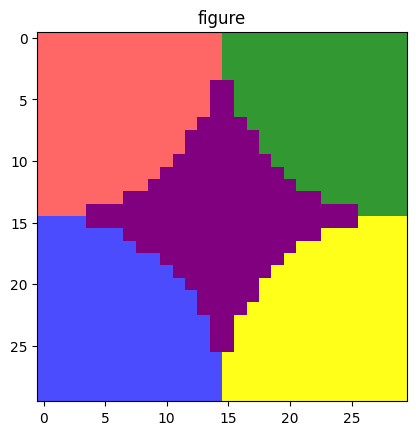

In [43]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

for the evaluations we will need to compare resulting Uhats to a Utrue and the U true needs to be collapsed into only the parcel of interest (parcel 5 and everything else)

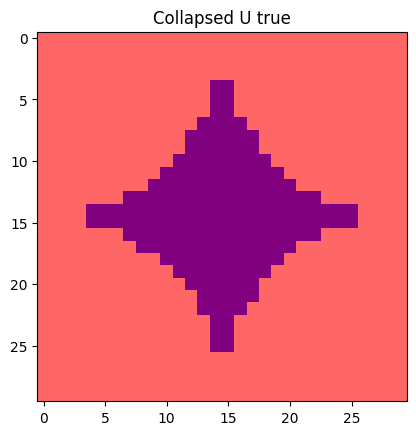

In [44]:
everything_else = U_true_5[ :4, :].sum(dim=0, keepdim=True)
parcel_of_interest = U_true_5[ 4:, :]
collapsed_U_true = pt.cat([everything_else, parcel_of_interest], dim=0).to(device)  

plot_Us(collapsed_U_true.cpu().numpy(), title='Collapsed U true')

# Make a random task battery with 100 task and plot second moment matrix

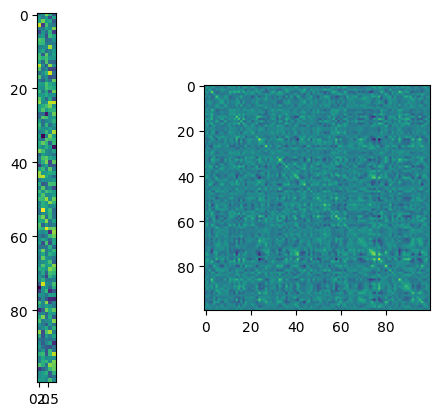

In [45]:
num_task_lib = 100
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

# prep inputs

In [46]:
Y_true = V_lib @ np.array(U_true_5)
Y_true = Y_true.reshape(1,Y_true.shape[0],Y_true.shape[1])
U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])


In [47]:
Y_true = pt.tensor(Y_true, dtype=pt.float32, device=device)
V_lib = pt.tensor(V_lib, dtype=pt.float32, device=device)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32,device=device)

C:\Users\barafat\AppData\Local\Temp\ipykernel_13508\504040485.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_true_5 = pt.tensor(U_true_5, dtype=pt.float32,device=device)


# Run

for this simulation, I will test multitasklocalizers of different n_tasks and compare to the single contrast localizer (different thresholds)

In [48]:
battery_sizes = [3,4,6,8,10,14,18,24,28]
n_batteries = 100000
noise = 5
max_n_task = max(battery_sizes)

In [49]:
multitask_localizers = []
for battery_size in battery_sizes:
    print(f'battery size: {battery_size}')
# Generate possible battery combinations for current battery size and calculate eigenmetrics
    D = ct.build_combinations(G_lib=G_lib, strategy='random',n_batteries=n_batteries,n_tasks=battery_size,seed=1,replacement=False,rest_idx=None)
    # pick the row with biggest log_det_mc column
    D_top = D[D['log_det_mc'] == D['log_det_mc'].max()]
    combination = D_top['combination'].values[0]
    weighted_noise = np.sqrt(noise * (battery_size / max_n_task))

    # Normalize VLib subset
    VLib_subset = V_lib[combination, :]
    VLib_subset = ut.center_matrix(VLib_subset, axis=0)
    VLib_subset = ut.normalize_matrix(VLib_subset, axis=0)


    # Add noise based on the weighted or fixed method
    YLib_subset = Y_true[:, combination, :]
    YLib_subset = YLib_subset + pt.normal(0, weighted_noise, YLib_subset.shape, device=device)
    YLib_subset = ut.center_matrix(YLib_subset, axis=1)
    YLib_subset = ut.normalize_matrix(YLib_subset, axis=1)

    # Build the parcellation
    U_hats = et.estimate_Us(YLib_subset, VLib_subset, method='correlation', hard=True)
    size_parcel_5 = int(sum(U_hats[0,4,:]).item())

    #collapse into 2 parcels (region of interest and everything else)
    everything_else = U_hats[:, :4, :].sum(dim=1, keepdim=True)
    parcel_of_interest = U_hats[:, 4:, :]
    collapsed_U_hat = pt.cat([everything_else, parcel_of_interest], dim=1)  
    collapsed_U_hat = collapsed_U_hat[0]
    multitask_localizers.append(collapsed_U_hat)



battery size: 3
battery size: 4
battery size: 6
battery size: 8
battery size: 10
battery size: 14
battery size: 18
battery size: 24
battery size: 28


# single dimensional localizer

In [50]:
regionA = 5 # region of interest
regionB = 4 # closest region, since the vs are random and all parcels are same size, this is arbitrary
n_task = 2 # 2 tasks single contrast

In [51]:
def find_single_contrast(Vs, regionA, regionB):
    """ Find the task that maximizes the difference between regionA and regionB """
    difference = Vs[:, regionA -1] - Vs[:, regionB-1]
    sorted_idx = pt.argsort(difference) 

    min_idx = sorted_idx[0].item()
    max_idx = sorted_idx[-1].item()

    return [max_idx, min_idx]

def thresholded_contrast(task1, task2, threshold):
    """gets the contrast between two tasks and thresholds it"""
    contrast_data = task1 - task2
    thresholded_data = pt.zeros_like(contrast_data)
    percentile = pt.quantile(contrast_data, threshold)
    thresholded_data[contrast_data >= percentile] = 1
    return thresholded_data

# get the indices of the tasks that maximize the difference between regionA and regionB
contrast_indices = find_single_contrast(V_lib, regionA, regionB)
task_1_idx = contrast_indices[0]
task_2_idx = contrast_indices[1]

# get the amount of noise to add to the data should be proportional to the number of tasks (less tasks here so you would get less noise since you have more of it)
weighted_noise = np.sqrt(noise * (n_task / max_n_task))

# get the data for the tasks that maximize the difference between regionA and regionB
task_1_data = Y_true[:,task_1_idx,:] + pt.normal(0, weighted_noise, Y_true[:,task_1_idx,:].shape, device=device)
task_2_data = Y_true[:,task_2_idx,:] + pt.normal(0, weighted_noise, Y_true[:,task_2_idx,:].shape, device=device)


In [52]:
thresholds = [0.2,0.4,0.6,0.8,0.9,0.95,0.99]
single_localizers = []
for threshold in thresholds:
    thresholded_mask = thresholded_contrast(task_1_data, task_2_data, threshold)
    one_hot = pt.nn.functional.one_hot(thresholded_mask.long(), num_classes=2).squeeze(0).T
    single_localizers.append(one_hot)

# evaluate both types of localizers

In [53]:
# compare each single contrast localizer (different thresholds) to the collapsed true parcellation
single_localizer_corrs = []
for localizer in single_localizers:
    corr = sim.get_dice_coefficient(collapsed_U_true, localizer)
    single_localizer_corrs.append(corr)

# compare each multitask localizer to the collapsed true parcellation
multitask_localizer_corrs = []
for localizer in multitask_localizers:
    corr = sim.get_dice_coefficient(collapsed_U_true, localizer)
    multitask_localizer_corrs.append(corr)
    

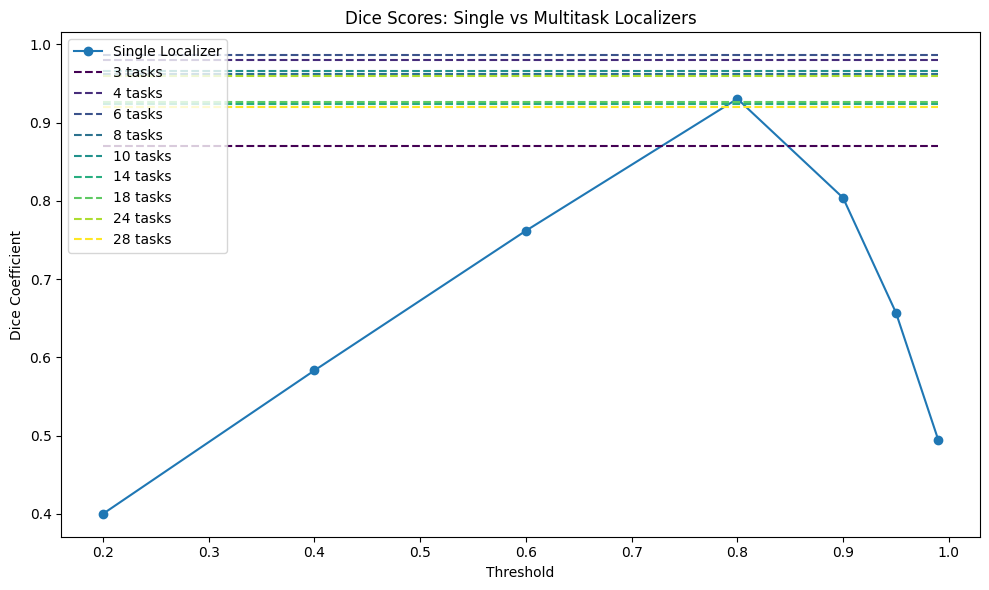

In [54]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
plt.figure(figsize=(10, 6))

# single contrast localizer Dice scores
plt.plot(thresholds, single_localizer_corrs, marker='o', label='Single Localizer')

# flat lines for each multitask localizer
colors = cm.viridis(np.linspace(0, 1, len(multitask_localizer_corrs)))

for i, (dice, size) in enumerate(zip(multitask_localizer_corrs, battery_sizes)):
    plt.hlines(dice, xmin=thresholds[0], xmax=thresholds[-1],
               linestyles='dashed', color=colors[i], label=f'{size} tasks')

plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
plt.title('Dice Scores: Single vs Multitask Localizers')
plt.legend()
plt.tight_layout()
plt.show()